In [8]:
#import required packages
import numpy as np
import geopandas as gpd
import rasterio
from shapely.geometry import LineString
import matplotlib.pyplot as plt

In [9]:
import pandas as pd

#open the observed data, select sheet and clip columns
dfRaw = pd.read_excel('../xls/Observed_Head.xlsx', sheet_name='Water Level Head & Temp')
dfRaw = dfRaw.rename(columns={'Unnamed: 41':'ElevRaw'})
dfRaw = dfRaw.iloc[2:,40:42]
dfRaw = dfRaw.set_index('SW1')
dfRaw['waterStage'] = dfRaw.ElevRaw + 3.4 #fix on the datum
dfRaw.head()

/home/hatari/.local/lib/python3.12/site-packages/pandas/core/indexes/base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


,ElevRaw,waterStage
SW1,,
2023-01-01 00:00:00,145.511681,148.911681
2023-01-01 01:00:00,145.526299,148.926299
2023-01-01 02:00:00,145.543689,148.943689
2023-01-01 03:00:00,145.555649,148.955649
2023-01-01 04:00:00,145.570253,148.970253


<AxesSubplot: xlabel='SW1'>

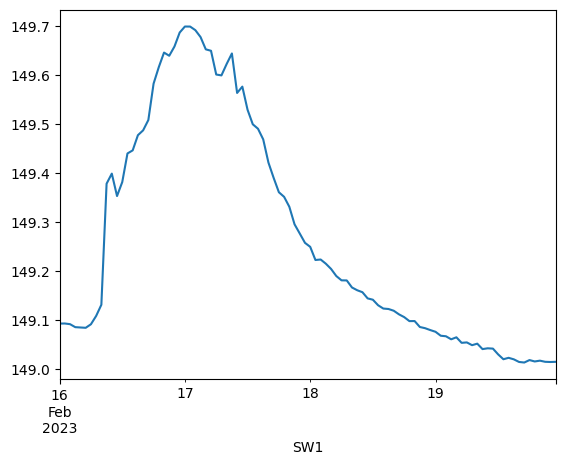

In [10]:
dfRaw.loc['2023-02-16':'2023-02-19', 'waterStage'].plot()

In [11]:
#!pip install h5py --break-system-packages
import h5py
import numpy as np
import pandas as pd
import geopandas as gpd
from scipy.spatial import KDTree
import matplotlib.pyplot as plt

In [12]:
hdfPath = '../Hec/HecCalibration/theisNash2.p01.hdf'
AreaName = '2D Flow Area'

In [13]:
sw1Df = gpd.read_file('../Shp/SW1.shp')
sw1Coords = list(sw1Df.iloc[0].geometry.coords)[0]
sw1Coords

(697308.6910000006, 4345781.995000001)

In [14]:
hdf = h5py.File(hdfPath,'r')

#cellInfoPath = f"Geometry/2D Flow Areas/{AreaName}/Cells Center Coordinate"
#cellCentroids = hdf[cellInfoPath][:]

cellCentroidsArray = np.asarray(hdf['Geometry']['2D Flow Areas']['Cell Points'])
cellCentroidsArray[:5]

array([[ 697293.70114532, 4345868.42012913],
       [ 697295.70114532, 4345868.42012913],
       [ 697289.70114532, 4345866.42012913],
       [ 697291.70114532, 4345866.42012913],
       [ 697293.70114532, 4345866.42012913]])

In [15]:
spatialIndex = KDTree(cellCentroidsArray)

In [16]:
timeBlocks = hdf['Results']['Unsteady']['Output']['Output Blocks']['Base Output']['Unsteady Time Series']['Time Date Stamp']
timeBlocksList = []
for timeBlock in timeBlocks:
    timeString = timeBlock.decode('utf-8').strip()
    timeDf = pd.to_datetime(timeString, format='%d%b%Y %H:%M:%S')
    timeBlocksList.append(timeDf)
timeBlocksList[:5]

[Timestamp('2023-02-16 00:00:00'),
 Timestamp('2023-02-16 01:00:00'),
 Timestamp('2023-02-16 02:00:00'),
 Timestamp('2023-02-16 03:00:00'),
 Timestamp('2023-02-16 04:00:00')]

In [17]:
surfaceDataset = hdf['Results']['Unsteady']['Output']['Output Blocks']['Base Output']['Unsteady Time Series']['2D Flow Areas']['Perimeter 1']['Water Surface']
surfaceDatasetArray = np.asarray(surfaceDataset)
surfaceDatasetArray[:2]

array([[148.64963, 148.64961, 148.64966, ..., 148.53296, 148.64934,
        147.95865],
       [148.72299, 148.72298, 148.72304, ..., 148.53296, 148.72221,
        147.95865]], dtype=float32)

In [18]:
distance, cellIndex = spatialIndex.query(sw1Coords)

In [19]:
print(distance)

1.077286895311947


In [20]:
print(cellIndex)

3978


In [21]:
#check position 
print(sw1Coords)
print(cellCentroidsArray[cellIndex])

(697308.6910000006, 4345781.995000001)
[ 697307.70114532 4345782.42012913]


In [22]:
#create modeled SW1 dataframe
sw1SimDf = pd.DataFrame()
sw1SimDf['Date'] = timeBlocksList
sw1SimDf['WSE'] = surfaceDatasetArray[:,cellIndex]
sw1SimDf = sw1SimDf.set_index(['Date'])
sw1SimDf


,WSE
Date,
2023-02-16 00:00:00,148.649536
2023-02-16 01:00:00,148.722763
2023-02-16 02:00:00,148.721115
2023-02-16 03:00:00,148.720001
2023-02-16 04:00:00,148.718048
...,...
2023-02-19 20:00:00,148.756866
2023-02-19 21:00:00,148.757050
2023-02-19 22:00:00,148.755920


(465696.0, 465792.0)

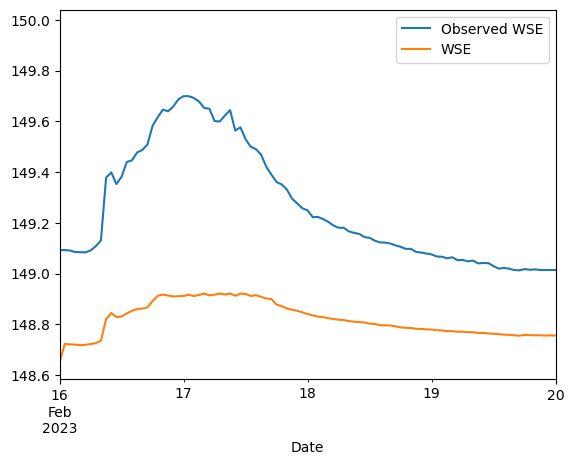

In [25]:
fig, ax = plt.subplots()
dfRaw['waterStage'].plot(ax=ax, label='Observed WSE')
sw1SimDf.plot(ax=ax)
ax.legend()
ax.set_xlim(sw1SimDf.index[0], sw1SimDf.index[-1])